In [ ]:
# !pip install keras-cv==0.6.1 keras-core==0.1.0 tensorflow==2.13.1 tensorflow-datasets==4.9.7

# %pip install --upgrade --quiet keras-hub keras

Note: you may need to restart the kernel to use updated packages.


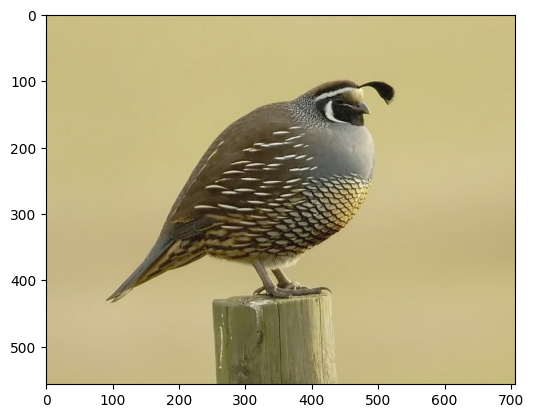

In [1]:
import keras
import numpy as np
import matplotlib.pyplot as plt

import requests

image_url = "https://upload.wikimedia.org/wikipedia/commons/a/aa/California_quail.jpg"

IMAGE_FILENAME = "california_quail.jpg"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(image_url, headers=headers)
with open(IMAGE_FILENAME, "wb") as f:
	f.write(response.content)

image = keras.utils.load_img(IMAGE_FILENAME)
plt.imshow(image)

In [15]:
import keras_hub

image_classifier = keras_hub.models.ImageClassifier.from_preset(
    # "resnet_50_imagenet",
    preset="bert_base_en",  ################ <========= unable to find preset
    activation="softmax",
)
batch = np.array([image])
image_classifier.preprocessor.image_size = (224, 224)
preds = image_classifier.predict(batch)
preds.shape
preds[0, :10]
preds[0].argmax()


ValueError: Unable to find a subclass of ImageClassifier that is compatible with BertBackbone found in preset 'bert_base_en'.

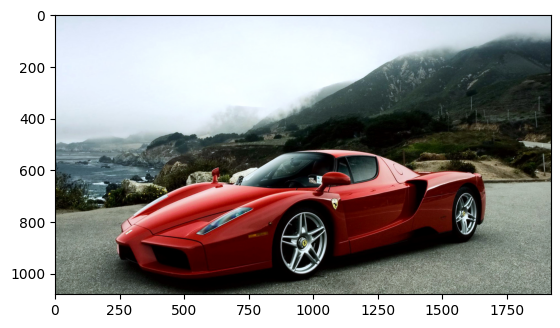

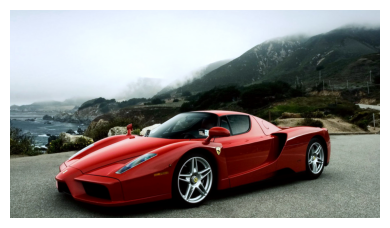

In [5]:
# url = 'https://i.redd.it/twpfhcw58xgb1.jpg'
# url = 'https://i.redd.it/aq53vqeaz5nb1.jpg'
url = 'https://wallup.net/wp-content/uploads/2014/10/cars/Ferrari_Enzo_Sport_Car_HD.jpg'
filepath = keras.utils.get_file(origin=url)
image = keras.utils.load_img(filepath)
plt.imshow(image)

images = np.array(image)
h, w, c = images.shape
image_batch = images.reshape((1, h, w, c))


import keras_cv

keras_cv.visualization.plot_image_gallery(
  image_batch, rows=1, cols=1, value_range=(0, 255), show=True, scale=4
)

In [8]:

import keras_cv

model = keras_cv.models.ImageClassifier.from_preset(
  "efficientnetv2_b0_imagenet_classifier"
)

probs = model.predict(image_batch)
probs.shape


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


(1, 1000)

In [9]:
top_classes = (-probs[0]).argsort()

In [10]:
top_classes[:5]

array([479, 976, 147, 817, 978])

In [11]:
label_name_url = 'https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/kerascv/imagenet_label_names.json'

# %pip install requests

import requests

label_names = requests.get(label_name_url).json()

In [12]:
label_names

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead shark',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'American robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'American dipper',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'fire salamander',
 'smooth newt',
 'newt',
 'spotted salamander',
 'axolotl',
 'American bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead sea turtle',
 'leatherback sea turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'green iguana',
 'Carolina anole',
 'desert grassland whiptail lizard',
 'agama',
 'frilled-necked lizard',
 'alligator lizard',
 'Gila monster',
 'European green lizard',
 'chameleon',
 'Komodo dragon',
 'Nile crocodile',
 'American alligator',
 'triceratops',
 'worm snake',
 'ring-necked snake',
 'eastern hog-nosed snake',
 'smooth green snake',
 'kingsnake',
 'garter snake',
 'water snake',
 'vin

In [13]:
for c in top_classes[:5]:
  print(label_names[c])

car wheel
promontory
grey whale
sports car
seashore
